# Loadings plot

Where the scores plot shows the observations, the loadings plot shows the **variables**: how much each one contributes to a single component. Each variable gets a bar drawn from a line at zero, so the sign and the magnitude both read at a glance.

    plot_loadings(loadings; comp = 1, varnames = ..., ntop = ..., nonzero = ..., kwargs...)

It takes a loadings matrix with variables in rows and components in columns. Every model in `BigRiverEssence` stores one in that layout already, so nothing needs transposing:

| Model | Call |
|---|---|
| `pca` | `plot_loadings(m.loadings; ntop = 20)` |
| `plskern` | `plot_loadings(m.P; ntop = 20)` |
| `plsda` | `plot_loadings(m.loadings_X; ntop = 20)` |
| `cca` | `plot_loadings(m.xproj)` |
| `spc` | `plot_loadings(m.loadings; nonzero = true, style = :sticks)` |
| `splsda` | `plot_loadings(m.loadings_X; nonzero = true, style = :sticks)` |
| `scca` | `plot_loadings(m.u; nonzero = true, style = :sticks)` |
| `pmd` | `plot_loadings(m.v; nonzero = true, style = :sticks)` |
| `jive` | `plot_loadings(m.U[i])` |

The two-block models draw their Y side the same way, from `m.loadings_Y`, `m.yproj` or `m.v`.

## Setup

In [1]:
using BigRiverEssence
using WolfRiverPlots
using Plots
using StableRNGs

## A simulated example

We use the same data as the scores notebook, so the two sets of figures describe one fit from both sides. Three latent signals drive twenty variables, plus a little noise — so we expect a handful of variables to carry most of the weight on each component and the rest to sit near zero.

We also name the variables here. Names matter more for this plot than for the scores, since the variable axis is what we read.

In [2]:
rng = StableRNG(20240801)

n = 90    # observations
p = 20    # variables

latent = randn(rng, n, 3)
X = latent * randn(rng, 3, p) .+ 0.3 .* randn(rng, n, p)

# names for the variable axis
vnames = ["gene$(i)" for i in 1:p]

m = pca(X; k = 5)

size(m.loadings)   # variables by components

(20, 5)

## The default plot

Given nothing but the loadings, we get the first component, every variable in its original order, ticked by index, with a line at zero separating the positive contributions from the negative.

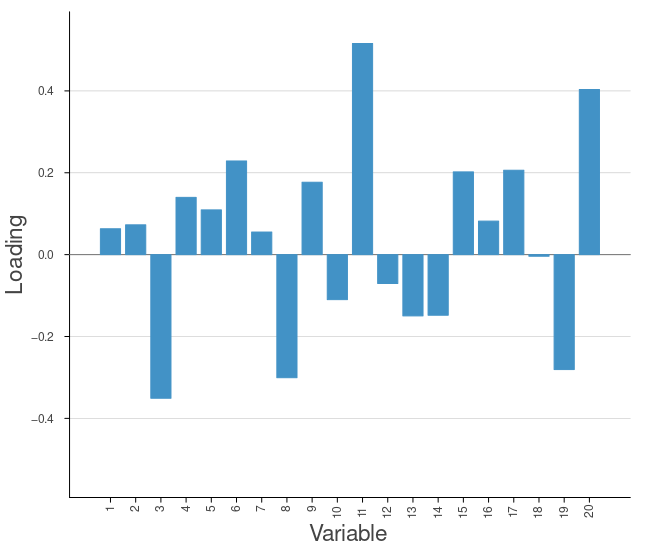

In [3]:
plot_loadings(m.loadings)

---

# Modifying the plot

Three arguments change **which loadings we draw** — `comp`, `ntop` and `nonzero` — and are applied before the plot is built. Everything else changes how it looks: `style` for bars against sticks, two color knobs, and the whole standard `Plots` vocabulary.

## Choosing what to draw

`comp` picks the component — the first is drawn by default. `varnames` names the variables; we pass them as an argument rather than setting `xticks`, because they are subset along with the loadings, so whichever variables survive keep their correct names. `ntop` keeps only the variables with the largest absolute loading — the ones actually driving the component — leaving them in their original order rather than sorting them.

Over many variables `ntop` is what keeps the axis legible, and it is what we reach for with the dense models. The axis label does not follow `comp`, so when we move off the first component we say so ourselves.

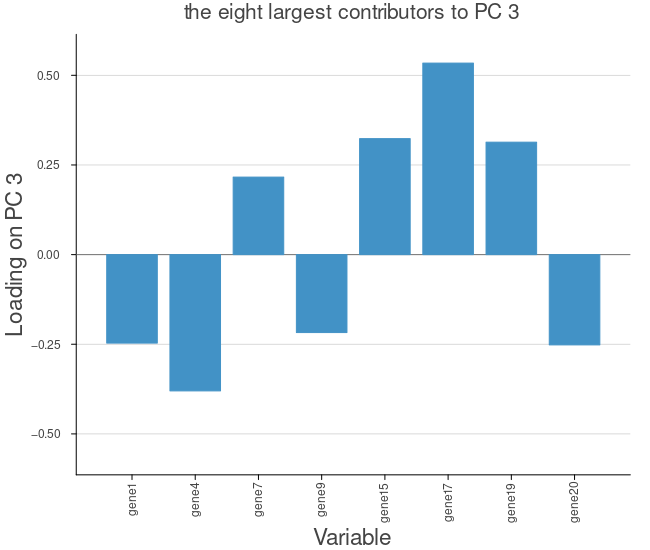

In [4]:
plot_loadings(m.loadings;
              comp     = 3,
              varnames = vnames,
              ntop     = 8,
              ylabel   = "Loading on PC 3",
              title    = "the eight largest contributors to PC 3")

## The sparse models

Models with an L1 penalty (`spc`, `pmd`, `splsda`, `scca`) push most loadings to exactly zero. Drawing all of them wastes the axis on empty bars, so `nonzero` keeps only the variables that survived the penalty, and `loadingsstyle = :sticks` swaps the bars for stems — a stem reads sparsity better, putting the emphasis on the few variables present rather than on the width of each bar.

Our PCA is dense, so `nonzero` changes nothing here and the figure below is really just showing the stick style. On a sparse fit these two together are what make the plot readable.

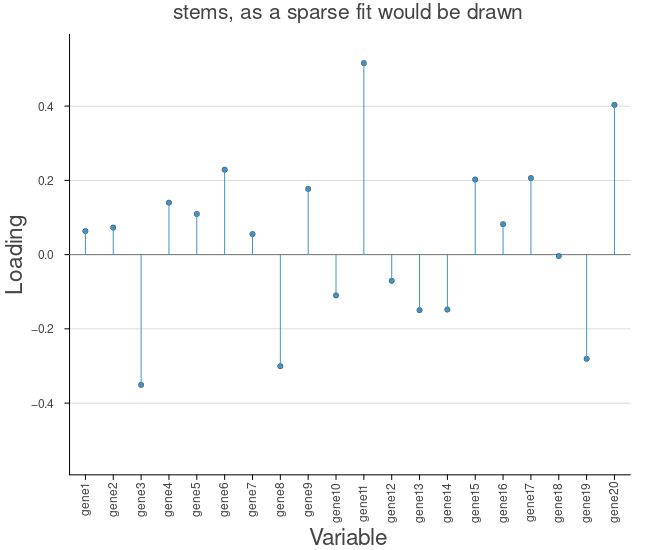

In [9]:
plot_loadings(m.loadings;
              varnames = vnames,
              nonzero  = true,
              loadingsstyle    = :sticks,
              title    = "stems, as a sparse fit would be drawn")

## Colors and the rest

Two color knobs of our own: `loadingscolor` for the bars and `origincolor` for the line at zero, which defaults to a light shade so it reads as a reference rather than as data.

Everything the plot sets for itself is a default that yields to whatever we pass, so the full `Plots` vocabulary is available alongside them — title, fonts, canvas size, legend.

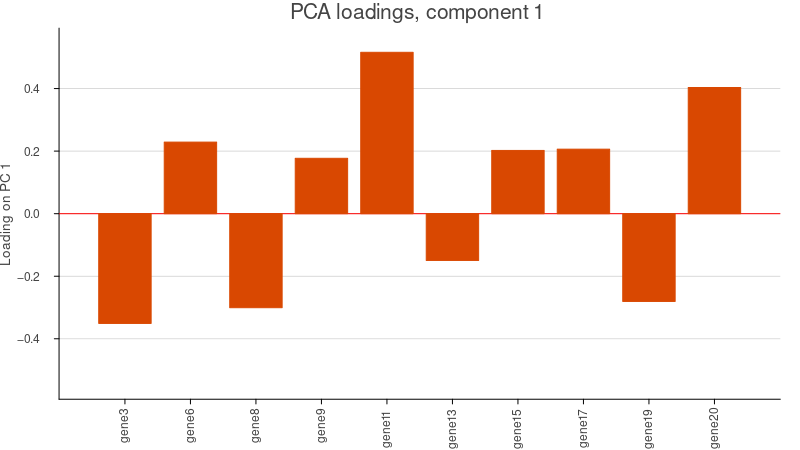

In [14]:
plot_loadings(m.loadings;
              varnames      = vnames,
              ntop          = 10,
              loadingscolor = "#d94801",
              origincolor   = :red,
              ylabel        = "Loading on PC 1",
              title         = "PCA loadings, component 1",
              size          = (800, 450),
              guidefontsize = 9,
              legend        = false)

## Summary

| Argument | What it does | Default |
|---|---|---|
| `loadings` | variables by components matrix | required |
| `comp` | which component to draw | `1` |
| `varnames` | one name per variable, subset along with the loadings | index numbers |
| `ntop` | keep the variables of largest absolute loading | `0`, meaning all |
| `nonzero` | keep only the variables whose loading is not zero | `false` |
| `loadingsstyle` | `:sticks` for a stem instead of a bar | bars |
| `loadingscolor` | color of the bars | — |
| `origincolor` | color of the line at zero | light grey |

Any other `Plots` attribute may be passed and will override the default.

**A rule of thumb:** dense models want `ntop`, sparse models want `nonzero` together with `style = :sticks`.